# Phase 2 — Data Wrangling & Exploratory Data Analysis
**House Price Prediction — Regression Capstone**

This notebook performs full data audit, cleaning, outlier detection, encoding, and 8+ visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
os.makedirs("../reports/figures", exist_ok=True)

train = pd.read_csv("../data/raw/train.csv")
print(f"Shape: {train.shape}")

Shape: (1460, 81)


## 1. Full Data Audit

In [2]:
audit = pd.DataFrame({
    "dtype": train.dtypes,
    "nulls": train.isnull().sum(),
    "null_pct": (train.isnull().sum() / len(train) * 100).round(1),
    "unique": train.nunique(),
    "sample": [train[c].dropna().iloc[0] if not train[c].dropna().empty else "" for c in train.columns]
})
audit

,dtype,nulls,null_pct,unique,sample
Id,int64,0,0.0,1460,1
MSSubClass,int64,0,0.0,15,60
MSZoning,object,0,0.0,5,RL
LotFrontage,float64,259,17.7,110,65.0
LotArea,int64,0,0.0,1073,8450
...,...,...,...,...,...
MoSold,int64,0,0.0,12,2
YrSold,int64,0,0.0,5,2008
SaleType,object,0,0.0,9,WD
SaleCondition,object,0,0.0,6,Normal


## 2. Missing Value Treatment Strategy

In [3]:
null_pct = train.isnull().sum() / len(train) * 100
high_null = null_pct[null_pct > 80].index.tolist()
med_null = null_pct[(null_pct > 5) & (null_pct <= 80)].index.tolist()
low_null = null_pct[(null_pct > 0) & (null_pct <= 5)].index.tolist()

print(f"Drop (>80% missing): {high_null}" if high_null else "Drop: none")
print(f"Impute (5-80%): {med_null}" if med_null else "Impute: none")
print(f"Impute or drop (<5%): {low_null}" if low_null else "Low missing: none")

Drop (>80% missing): ['Alley', 'PoolQC', 'Fence', 'MiscFeature']
Impute (5-80%): ['LotFrontage', 'MasVnrType', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']
Impute or drop (<5%): ['MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical']


In [4]:
drop_cols = high_null + ["Id"]
train_clean = train.drop(columns=drop_cols, errors="ignore")
print(f"Dropped: {drop_cols}")
print(f"New shape: {train_clean.shape}")

Dropped: ['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'Id']
New shape: (1460, 76)


In [5]:
num_cols = train_clean.select_dtypes(include=[np.number]).columns
cat_cols = train_clean.select_dtypes(exclude=[np.number]).columns
for c in num_cols:
    if train_clean[c].isnull().sum() > 0:
        train_clean[c].fillna(train_clean[c].median(), inplace=True)
for c in cat_cols:
    if train_clean[c].isnull().sum() > 0:
        train_clean[c].fillna(train_clean[c].mode()[0], inplace=True)
print(f"Remaining nulls: {train_clean.isnull().sum().sum()}")

Remaining nulls: 0


C:\Users\PRO\AppData\Local\Temp\ipykernel_12616\192716936.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_clean[c].fillna(train_clean[c].median(), inplace=True)
C:\Users\PRO\AppData\Local\Temp\ipykernel_12616\192716936.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

F

## 3. Duplicate Check

In [6]:
dups = train_clean.duplicated().sum()
print(f"Duplicate rows: {dups}")

Duplicate rows: 0


## 4. Outlier Detection (IQR + Z-Score)

In [7]:
def find_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)].shape[0]

from scipy import stats
def find_outliers_zscore(df, col, threshold=3):
    z = np.abs(stats.zscore(df[col].dropna()))
    return (z > threshold).sum()

key_num = ["SalePrice", "LotArea", "GrLivArea", "TotalBsmtSF", "YearBuilt"]
results = []
for col in key_num:
    if col in train_clean.columns:
        iqr = find_outliers_iqr(train_clean, col)
        zsc = find_outliers_zscore(train_clean, col)
        results.append({"Feature": col, "IQR_outliers": iqr, "Zscore_outliers": zsc, "Total": len(train_clean)})
pd.DataFrame(results)

,Feature,IQR_outliers,Zscore_outliers,Total
0,SalePrice,61,22,1460
1,LotArea,69,13,1460
2,GrLivArea,31,16,1460
3,TotalBsmtSF,61,10,1460
4,YearBuilt,7,6,1460


## 5. Encoding Categorical Features

In [8]:
quality_map = {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
ordinal_cols = ["ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu", "GarageQual", "GarageCond", "PoolQC"]
for c in ordinal_cols:
    if c in train_clean.columns:
        train_clean[c] = train_clean[c].map(quality_map).fillna(0).astype(int)
        print(f"Ordinal encoded: {c}")

Ordinal encoded: ExterQual
Ordinal encoded: ExterCond
Ordinal encoded: BsmtQual
Ordinal encoded: BsmtCond
Ordinal encoded: HeatingQC
Ordinal encoded: KitchenQual
Ordinal encoded: FireplaceQu
Ordinal encoded: GarageQual
Ordinal encoded: GarageCond


In [9]:
remaining_cat = train_clean.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"One-hot encoding: {remaining_cat}")
train_encoded = pd.get_dummies(train_clean, columns=remaining_cat, drop_first=True)
print(f"Shape after encoding: {train_encoded.shape}")

One-hot encoding: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType', 'SaleCondition']
Shape after encoding: (1460, 213)


## 6. Visualizations (8+)

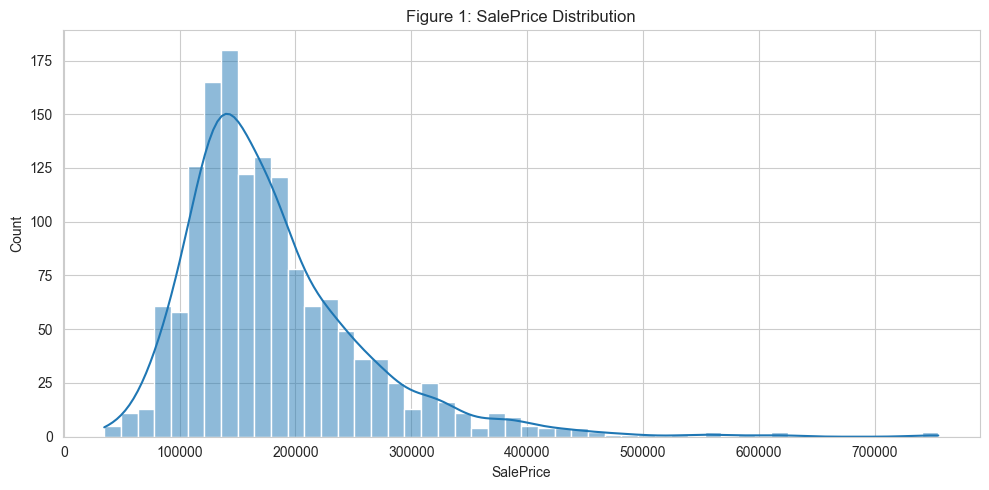

Insight: SalePrice is right-skewed. Log transform may help.


In [10]:
fig, ax = plt.subplots()
sns.histplot(train_encoded["SalePrice"], kde=True, bins=50, ax=ax)
ax.set_title("Figure 1: SalePrice Distribution")
plt.tight_layout()
plt.savefig("../reports/figures/fig1_saleprice_dist.png", dpi=150)
plt.show()
print("Insight: SalePrice is right-skewed. Log transform may help.")

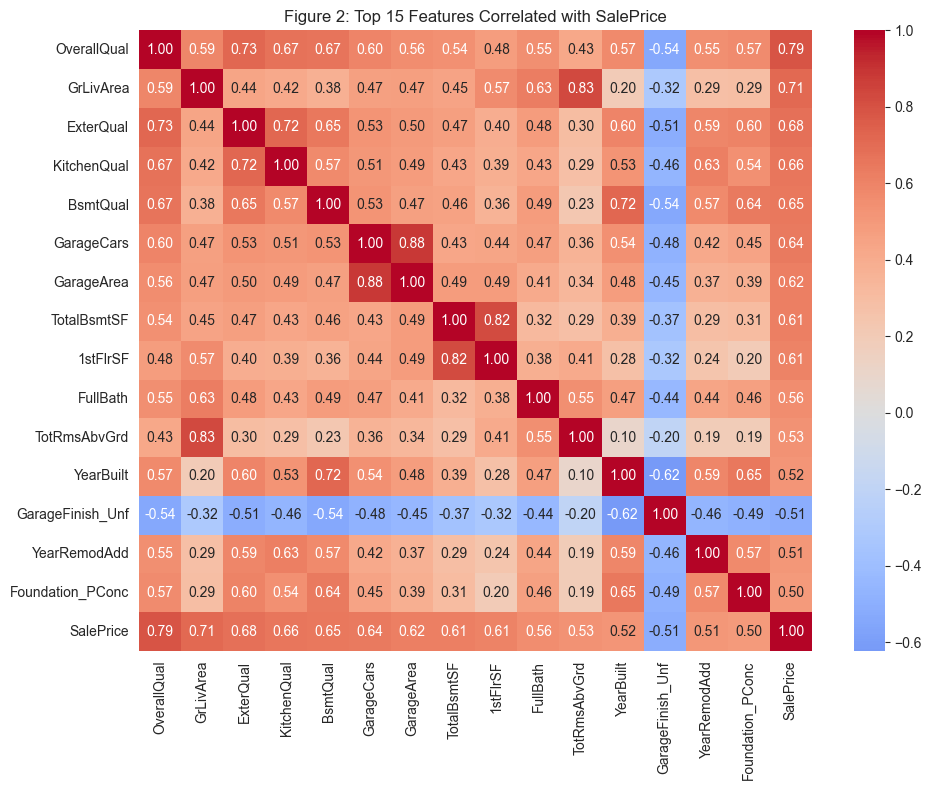

Insight: OverallQual, GrLivArea, and GarageCars are strongest predictors.


In [11]:
corr = train_encoded.corr()["SalePrice"].abs().sort_values(ascending=False)
top15 = corr.index[1:16]
plt.figure(figsize=(10, 8))
sns.heatmap(train_encoded[top15.tolist() + ["SalePrice"]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Figure 2: Top 15 Features Correlated with SalePrice")
plt.tight_layout()
plt.savefig("../reports/figures/fig2_correlation_heatmap.png", dpi=150)
plt.show()
print("Insight: OverallQual, GrLivArea, and GarageCars are strongest predictors.")

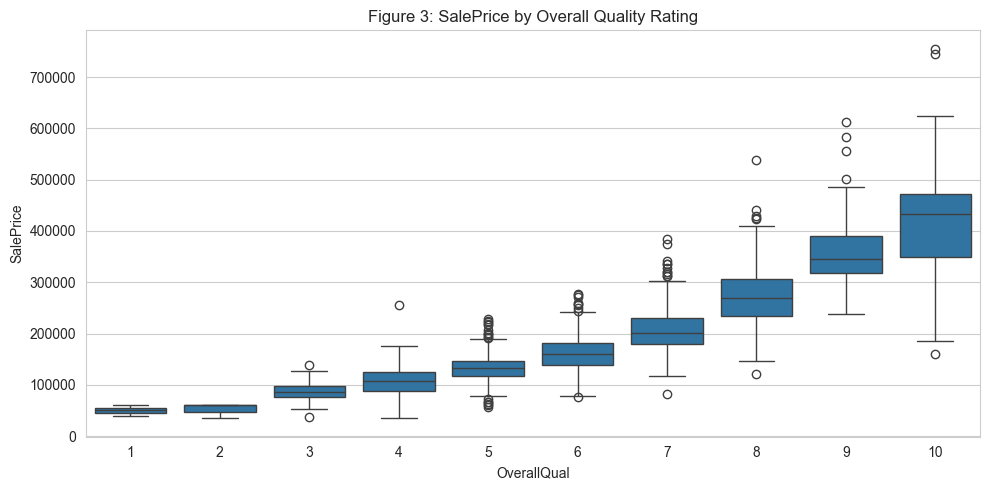

Insight: Higher quality drives higher prices (non-linear jump at 7+).


In [12]:
plt.figure()
sns.boxplot(x=train_clean["OverallQual"], y=train_clean["SalePrice"])
plt.title("Figure 3: SalePrice by Overall Quality Rating")
plt.tight_layout()
plt.savefig("../reports/figures/fig3_price_vs_quality.png", dpi=150)
plt.show()
print("Insight: Higher quality drives higher prices (non-linear jump at 7+).")

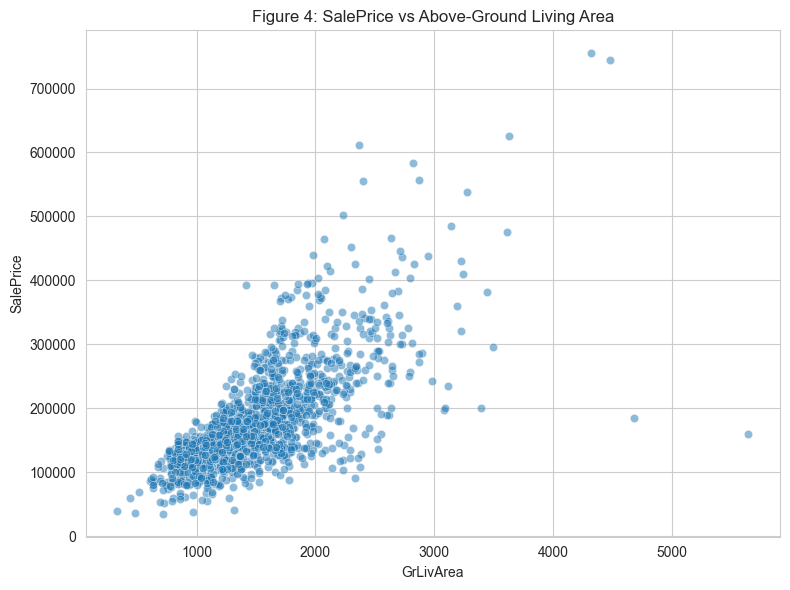

Insight: Positive correlation. Some high-area, low-price outliers.


In [13]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=train_clean["GrLivArea"], y=train_clean["SalePrice"], alpha=0.5)
plt.title("Figure 4: SalePrice vs Above-Ground Living Area")
plt.tight_layout()
plt.savefig("../reports/figures/fig4_price_vs_livingarea.png", dpi=150)
plt.show()
print("Insight: Positive correlation. Some high-area, low-price outliers.")

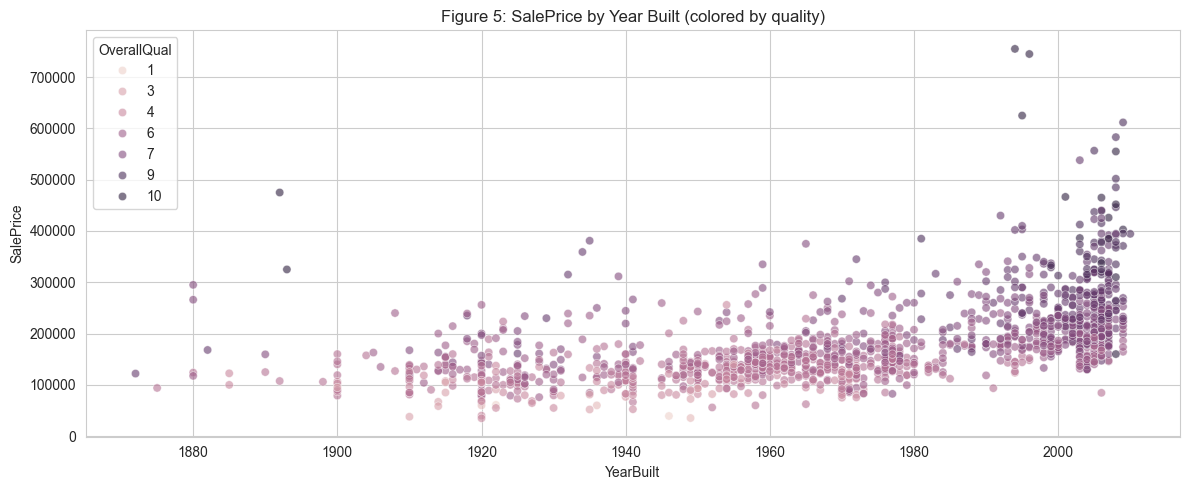

Insight: Newer homes are higher quality and more expensive.


In [14]:
plt.figure(figsize=(12, 5))
sns.scatterplot(x=train_clean["YearBuilt"], y=train_clean["SalePrice"], hue=train_clean["OverallQual"], alpha=0.6)
plt.title("Figure 5: SalePrice by Year Built (colored by quality)")
plt.tight_layout()
plt.savefig("../reports/figures/fig5_price_vs_yearbuilt.png", dpi=150)
plt.show()
print("Insight: Newer homes are higher quality and more expensive.")

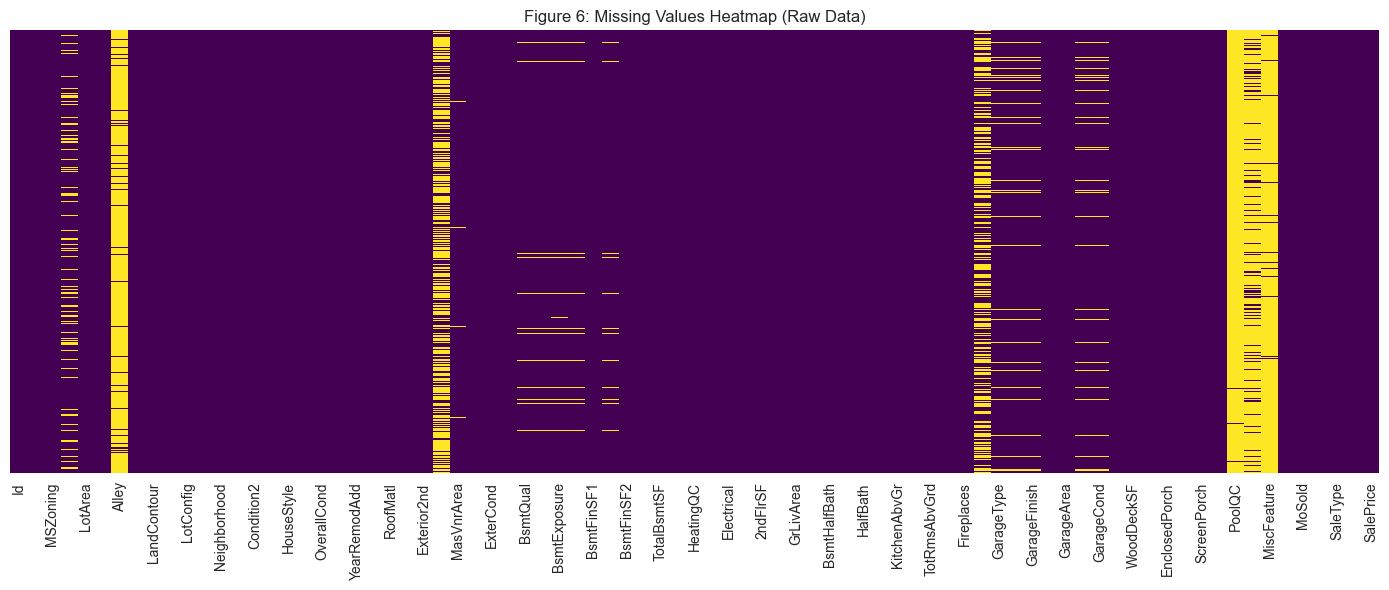

Insight: PoolQC, MiscFeature, Alley, Fence have >80% missing.


In [15]:
plt.figure(figsize=(14, 6))
sns.heatmap(train.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Figure 6: Missing Values Heatmap (Raw Data)")
plt.tight_layout()
plt.savefig("../reports/figures/fig6_missing_heatmap.png", dpi=150)
plt.show()
print("Insight: PoolQC, MiscFeature, Alley, Fence have >80% missing.")

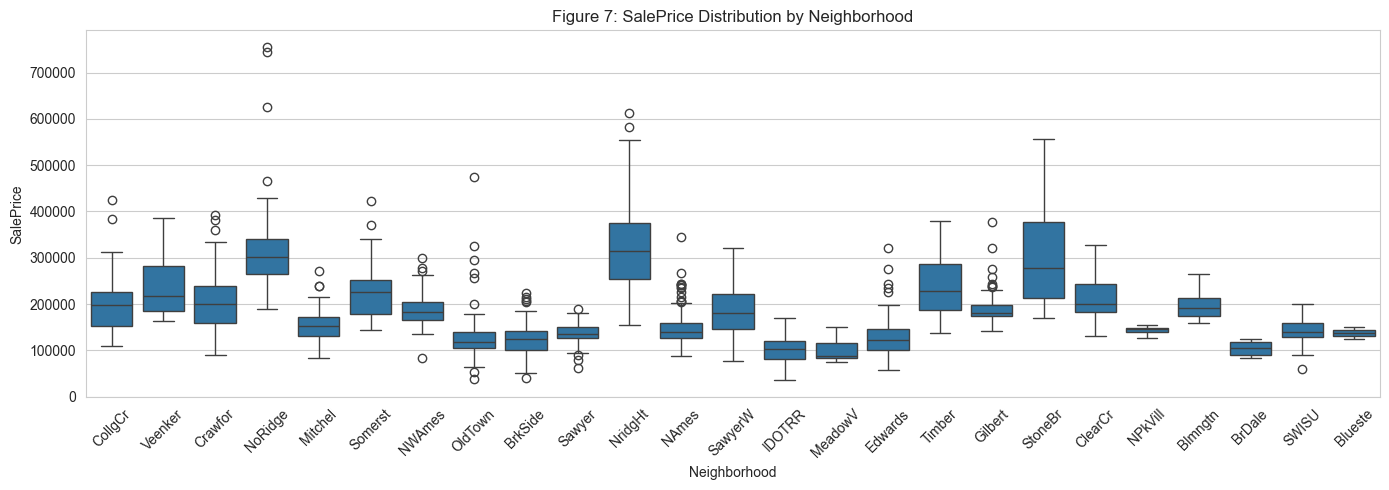

Insight: NoRidge and NridgHt have much higher median prices.


In [16]:
plt.figure(figsize=(14, 5))
sns.boxplot(x=train_clean["Neighborhood"], y=train_clean["SalePrice"])
plt.xticks(rotation=45)
plt.title("Figure 7: SalePrice Distribution by Neighborhood")
plt.tight_layout()
plt.savefig("../reports/figures/fig7_price_by_neighborhood.png", dpi=150)
plt.show()
print("Insight: NoRidge and NridgHt have much higher median prices.")

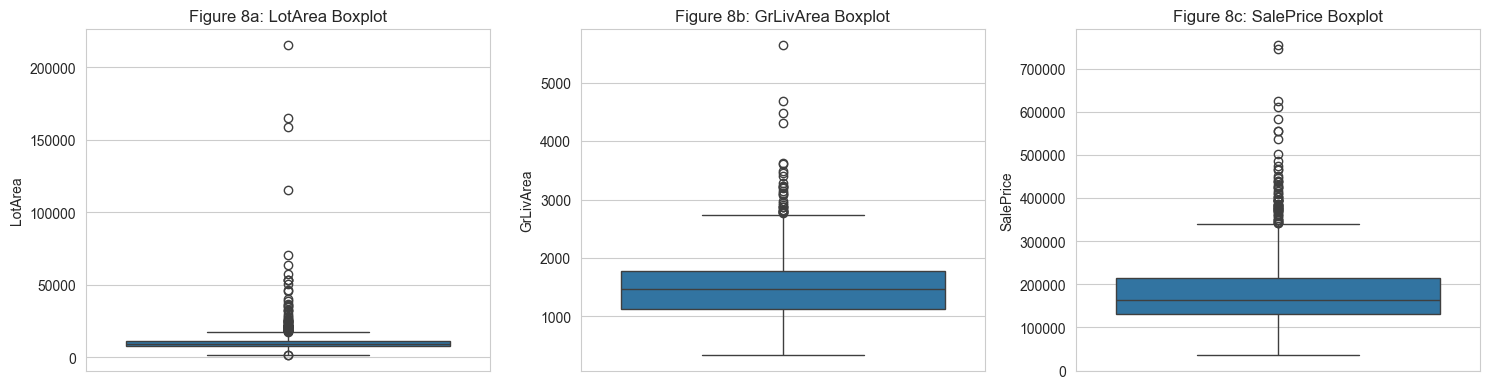

Insight: Upper-tail outliers in all three features.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=train_clean["LotArea"], ax=axes[0])
axes[0].set_title("Figure 8a: LotArea Boxplot")
sns.boxplot(y=train_clean["GrLivArea"], ax=axes[1])
axes[1].set_title("Figure 8b: GrLivArea Boxplot")
sns.boxplot(y=train_clean["SalePrice"], ax=axes[2])
axes[2].set_title("Figure 8c: SalePrice Boxplot")
plt.tight_layout()
plt.savefig("../reports/figures/fig8_outlier_boxplots.png", dpi=150)
plt.show()
print("Insight: Upper-tail outliers in all three features.")

## 7. Save Cleaned Data

In [18]:
os.makedirs("../data/processed", exist_ok=True)
train_encoded.to_csv("../data/processed/train_cleaned.csv", index=False)
print("Saved cleaned dataset to data/processed/train_cleaned.csv")

Saved cleaned dataset to data/processed/train_cleaned.csv


## 8. EDA Summary

### Three Most Important Findings:
1. **SalePrice is right-skewed** — log transformation will likely improve model fit.
2. **OverallQual is the strongest predictor** — a simple ordinal feature that captures building material/finish quality.
3. **Neighborhood matters significantly** — location effects are strong and should be encoded properly.

### Implications for Modelling:
- Log-transform the target variable to handle skewness.
- Use ensemble methods (Random Forest, XGBoost) that can capture non-linear interactions between quality, area, and neighborhood.
- Feature engineering should focus on interaction terms (e.g., total area = GrLivArea + TotalBsmtSF) and age-based features.